<img src = "https://drive.google.com/uc?export=view&id=1HYrQHu1AE2cEid3BpNxo5KK3tuZF1TCo" alt = "Encabezado MLDS" width = "100%">  </img>

# **Análisis de datos**
---

Este notebook es una plantilla que le puede servir como guía para el cuarto entregable del proyecto aplicado.

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. **JESUS ESCOBAR DIZZ**
2. **JUAN DAVID TULANDE GUTIERREZ**
3. **DIANA CELIA ZAMBRANO PINTO**

In [1]:
#LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.formula.api as smf
import plotly.express as px
import geopandas as gpd
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
import warnings


In [2]:
#Paleta de Colores Utilizado
PRIMARY_COLOR = "#1F4E78"
PALETTE_CATEGORICAL = [
    "#1F4E78",
    "#4682B4",
    "#76A5AF",
    "#A4C2F4",
    "#C9DAF8",
]

In [3]:
#Lectura del Archivo
url = 'https://raw.githubusercontent.com/JuanTulande/CSV/d71f16f5fdf272e247f3d3fbb1499e15637d20c8/dataset_final.csv'


df = pd.read_csv(url)
df = df.drop('Unnamed: 0', axis=1)
# Cambio en el formato de las variables:
df['GRUPO'] = df['GRUPO'].astype(str)
df['CONTAGIOSA'] = df['CONTAGIOSA'].astype(str)
df['CRONICA'] = df['CRONICA'].astype(str)
df['MORTALIDAD'] = df['MORTALIDAD'].astype(str)
df['FECHA REGISTRO'] = pd.to_datetime(df['FECHA REGISTRO'], format='mixed')

In [4]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324941 entries, 0 to 324940
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   FECHA REGISTRO   324941 non-null  datetime64[ns]
 1   DEPARTAMENTO     324941 non-null  object        
 2   MUNICIPIO        324941 non-null  object        
 3   CIE-10           324941 non-null  object        
 4   NOMBRE           324941 non-null  object        
 5   DESCRIPCION      324941 non-null  object        
 6   SISTEMA          324941 non-null  object        
 7   ENTIDAD REPORTA  324941 non-null  object        
 8   GRUPO            324941 non-null  object        
 9   CONTAGIOSA       324941 non-null  object        
 10  CRONICA          324941 non-null  object        
 11  MORTALIDAD       324941 non-null  object        
dtypes: datetime64[ns](1), object(11)
memory usage: 29.7+ MB


,FECHA REGISTRO,DEPARTAMENTO,MUNICIPIO,CIE-10,NOMBRE,DESCRIPCION,SISTEMA,ENTIDAD REPORTA,GRUPO,CONTAGIOSA,CRONICA,MORTALIDAD
0,2025-01-07,ATLÁNTICO,BARRANQUILLA,M199,"ARTROSIS, NO ESPECIFICADA",OTRAS ARTROSIS,RIPS,INS,ENFERMEDADES DEL SISTEMA OSTEOMUSCULAR Y DEL T...,No,Si,1
1,2025-01-10,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
2,2025-01-13,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
3,2025-01-24,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,INS,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
4,2025-01-24,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
5,2025-01-31,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
6,2025-01-13,MAGDALENA,SANTA MARTA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,SIVIGILA,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
7,2025-01-21,MAGDALENA,SANTA MARTA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
8,2025-01-22,MAGDALENA,SANTA MARTA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1
9,2025-01-23,MAGDALENA,SANTA MARTA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,No,1


## **1. Análisis y resultados**
---

Al adentrarse en el análisis de datos, es crucial adoptar un enfoque estratégico que responda a las preguntas de planteadas en el proyecto. La selección de variables para estudio requiere una evaluación cuidadosa de los objetivos específicos del proyecto, priorizando aquellas que se consideren fundamentales para obtener resultados significativos.

A lo largo de esta entrega, trate busque responder las siguientes preguntas

- ¿Cómo se aplicaron conceptos específicos de estadística descriptiva e inferencial en el análisis de datos y cuál fue el enfoque utilizado para interpretar los resultados de manera precisa?
- ¿Cómo se interpretaron los resultados de la estadística descriptiva y qué conclusiones se pueden extraer?
- ¿Cómo se relacionan los resultados del análisis de datos con los objetivos y preguntas planteadas inicialmente?
- ¿Qué implicaciones prácticas tienen los hallazgos y cómo podrían influir en la toma de decisiones?

### **1.1. Análisis de correlaciones**
---

- Analice la posible existencia de relaciones entre las variables, utilizando medidas de correlación o visualizaciones pertinentes.

Se analizaron las relaciones mediantes tablas de calor( comunmente denomindas heatmap) . Se  encontró una fuerte asociación entre la variable GRUPO y las varibles CONTAGIOSA y CRONICA. Por ejemplo, enfermedades infecciosas se vinculan
a categorias de tipo contagiosa y no cronicas, mientras que enfermedades cardiacas se asocian a cronicas y no contagiosa

- Detecte la presencia de redundancias entre las variables, con el objetivo de facilitar su posterior eliminación o selección en el análisis.

Se valido una redudancia, especialmente en las variabes CIE-10, NOMBRE, DESCRIPCION y GRUPO. Por ejemplo, un código CIE-10 determina una descripción algo ambigua. Es por ello que se ha tomado la desición de elegir la  variable GRUPO por ser una columna útil en la toma de desiciones estrategicas

- ¿Cuáles fueron las variables seleccionadas para el análisis de correlaciones, y cómo se eligieron en función de los objetivos del proyecto?



Se selecionarion GRUPO, CONTAGIOSA, CRONICA ,  MORTALIDAD y MUNICIPIO. estas columnas dentro del conjunto de datos fueron elegidas debido a que permiten identificar la naturaleza del evento en salud




Prueba Chi-Cuadrado (GRUPO vs CONTAGIOSA):
Estadístico Chi2: 197048.8197, p-valor: 0.0000e+00
Coeficiente V de Cramer: 0.7787



/tmp/ipykernel_1511/826354797.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


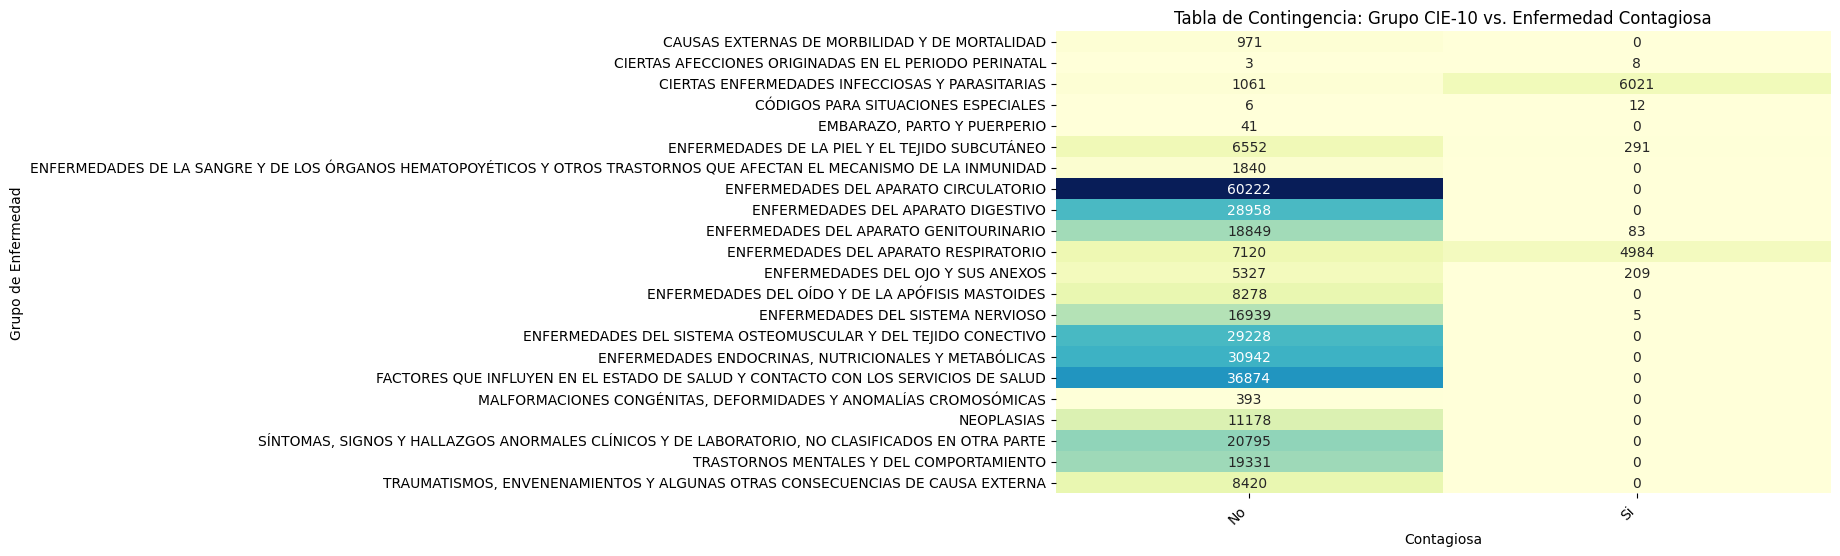

In [5]:
#ANALISIS DE CORRELACIONES ENTRE VARIABLES : GRUPO VS CONTAGIOSA
df['GRUPO'] = df['GRUPO'].str.strip()
tabla_grupo_mor = pd.crosstab(df['GRUPO'], df['CONTAGIOSA'])

# Prueba de Chi-Cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_grupo_mor)

# Calcular V de Cramer (Fuerza de la asociación)
v_cramer = association(tabla_grupo_mor, method='cramer')

print(f"Prueba Chi-Cuadrado (GRUPO vs CONTAGIOSA):")
print(f"Estadístico Chi2: {chi2:.4f}, p-valor: {p_value:.4e}")
print(f"Coeficiente V de Cramer: {v_cramer:.4f}\n")

# Visualización de la tabla de contingencia
plt.figure(figsize=(10, 6))
sns.heatmap(tabla_grupo_mor, annot=True, fmt="d", cmap="YlGnBu", cbar=False ,)
plt.title('Tabla de Contingencia: Grupo CIE-10 vs. Enfermedad Contagiosa')
plt.xlabel('Contagiosa')
plt.ylabel('Grupo de Enfermedad')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

El p-valor es esencialmente cero, esto significa que se rechaza contundentemente la hipótesis nula de independencia: hay evidencia estadística abrumadora de que el GRUPO de enfermedad y la variable CONTAGIOSA no son independientes entre sí, es decir, saber a qué grupo pertenece un caso sí te da información sobre si es contagioso o no. Si hablamos del coeficiente de Cramer un valor de 0.78 se considera una asociación fuerte a muy fuerte

Prueba Chi-Cuadrado (GRUPO vs CRONICA):
Estadístico Chi2: 238668.0596, p-valor: 0.0000e+00
Coeficiente V de Cramer: 0.8570



/tmp/ipykernel_1511/1045759185.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


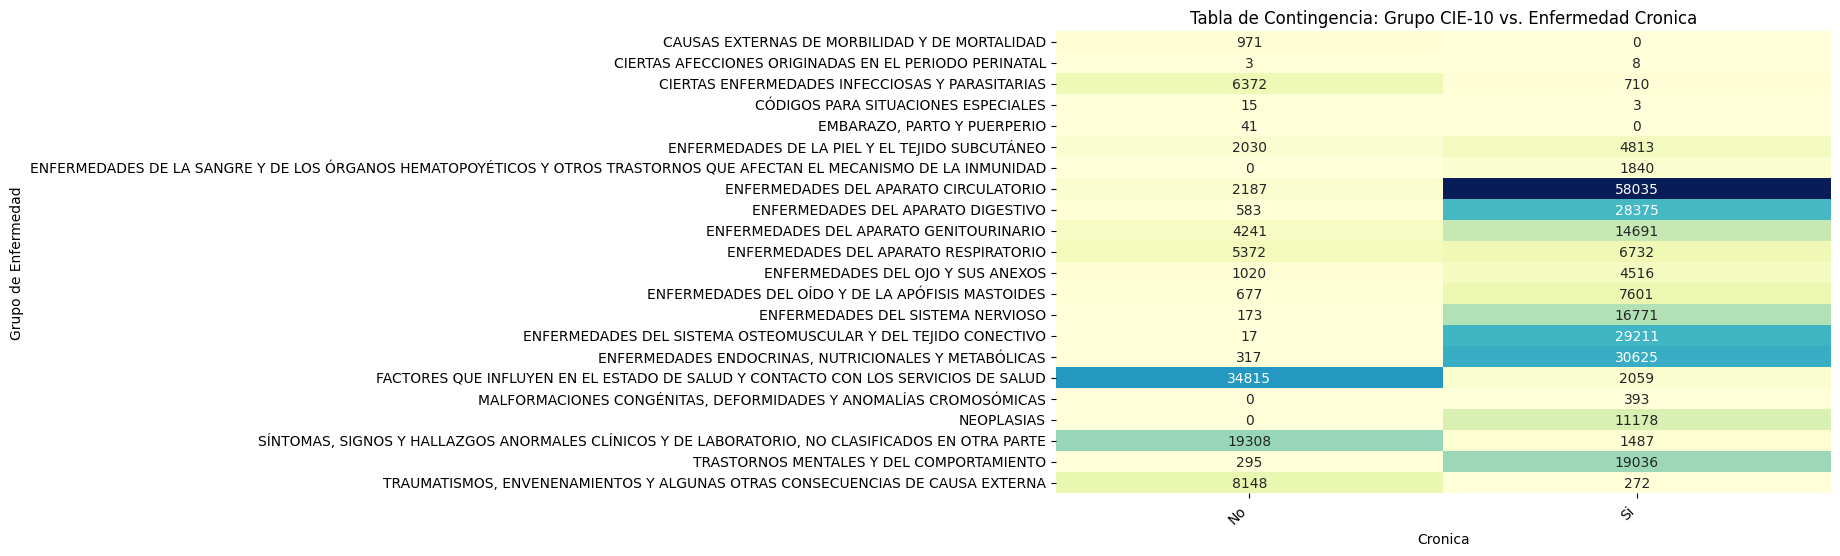

In [6]:
#ANALISIS DE CORRELACIONES ENTRE VARIABLES : GRUPO VS CRONICA
tabla_grupo_cron = pd.crosstab(df['GRUPO'], df['CRONICA'])

# Prueba de Chi-Cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_grupo_cron)

# Calcular V de Cramer (Fuerza de la asociación)
v_cramer = association(tabla_grupo_cron, method='cramer')

print(f"Prueba Chi-Cuadrado (GRUPO vs CRONICA):")
print(f"Estadístico Chi2: {chi2:.4f}, p-valor: {p_value:.4e}")
print(f"Coeficiente V de Cramer: {v_cramer:.4f}\n")

# Visualización de la tabla de contingencia
plt.figure(figsize=(10, 6))
sns.heatmap(tabla_grupo_cron, annot=True, fmt="d", cmap="YlGnBu", cbar=False ,)
plt.title('Tabla de Contingencia: Grupo CIE-10 vs. Enfermedad Cronica')
plt.xlabel('Cronica')
plt.ylabel('Grupo de Enfermedad')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


El p-valor prácticamente cero indica un rechazo contundente de la hipótesis nula de independencia. Hay evidencia estadísticamente abrumadora de que GRUPO y CRÓNICA no son independientes. Por parte del coeficiente de Cramer un valor de 0.857 indica una asociacion fuertisima entre ambas variablesy tiene sentido debido a que al analizar la naturaleza de cronica y grupo estan casi que definidos en uno por el otro como por ejemplo(las neoplasias y malformaciones congénitas son crónicas por definición; el embarazo/parto y las causas externas son, por definición, eventos agudos/puntuale).

Prueba Chi-Cuadrado (CONTAGIOSA VS CRONICA):
Estadístico Chi2: 28290.8808, p-valor: 0.0000e+00
Coeficiente V de Cramer: 0.2951



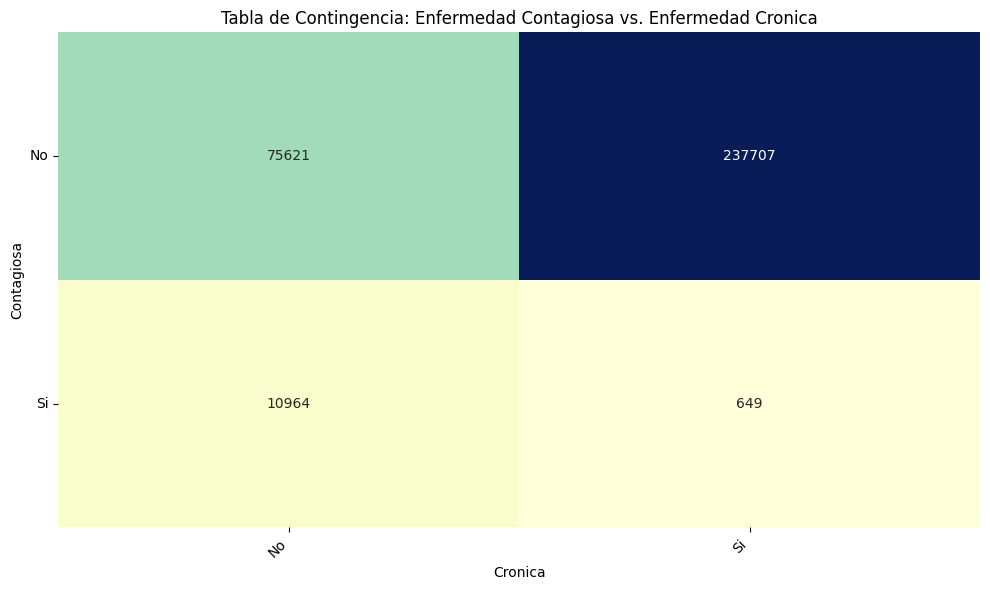

In [7]:
#ANALISIS DE CORRELACIONES ENTRE VARIABLES : CONTAGIOSA VS CRONICA
df['GRUPO'] = df['GRUPO'].str.strip()
tabla_cont_cron = pd.crosstab(df['CONTAGIOSA'], df['CRONICA'])

# Prueba de Chi-Cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_cont_cron)

# Calcular V de Cramer (Fuerza de la asociación)
v_cramer = association(tabla_cont_cron, method='cramer')

print(f"Prueba Chi-Cuadrado (CONTAGIOSA VS CRONICA):")
print(f"Estadístico Chi2: {chi2:.4f}, p-valor: {p_value:.4e}")
print(f"Coeficiente V de Cramer: {v_cramer:.4f}\n")

# Visualización de la tabla de contingencia
plt.figure(figsize=(10, 6))
sns.heatmap(tabla_cont_cron, annot=True, fmt="d", cmap="YlGnBu", cbar=False ,)
plt.title('Tabla de Contingencia: Enfermedad Contagiosa vs. Enfermedad Cronica')
plt.xlabel('Cronica')
plt.ylabel('Contagiosa')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

El p-valor prácticamente cero indica que se rechaza con contundencia la hipótesis nula de independencia: CONTAGIOSA y CRÓNICA sí están asociadas. Por parte del coeficiente de Cramer un valor de 0.2951 indica una asociacion moderada, no es fuerte.

### **1.2. Análisis de regresiones**
---

- Apartir de las correlaciones identificadas, ¿es posible llevar a cabo un análisis de regresiones para estimar el valor de alguna de las variables de interés?

Sí, es posible, aunque debdio a que la variable de interés es de un envento practicamente binario( si es crónica o no, o si es mortal o no), no es posible usar una regresión lineal. Es por ello que se ha decidido usar una Regresión Logística Binaria

- ¿Cuáles fueron las variables seleccionadas para el análisis de regresiones y cómo se eligieron en función de los objetivos del proyecto?

Se seleciono cómo Variable dependiente CRONICA y como variables independintes CONTAGIOSA Y grupo. Todo ello con el fin de estimar la probabilidad de que un evento en salud sea crónico en funcíon de su naturaleza y clasificación Clínica. Esto nos permite evidenciar los dos grandes focos que se deben tomar en cuenta al hablar de  temas clínicos, puesto que enfermedades contagiosas requieren un mayor control en la parte epidemologica, mientras que enfermedades crónicas requieren más una atención en medicamentos, atención y de cobertura.


In [8]:
df['ES_CRONICA'] = (df['CRONICA'] == 'Si').astype(int)
df['ES_CONTAGIOSA'] = (df['CONTAGIOSA'] == 'Si').astype(int)

# Modelo Logístico: Predecir probabilidad de cronicidad
modelo_logit = smf.logit('ES_CRONICA ~ ES_CONTAGIOSA + C(GRUPO)', data=df).fit()
print(modelo_logit.summary())
# Calcular Odds Ratios (Razones de Momio) para interpretar el impacto
params = modelo_logit.params
conf = modelo_logit.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
print(np.exp(conf))

         Current function value: 0.170032
         Iterations: 35


/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


                           Logit Regression Results                           
Dep. Variable:             ES_CRONICA   No. Observations:               324941
Model:                          Logit   Df Residuals:                   324918
Method:                           MLE   Df Model:                           22
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                  0.7067
Time:                        00:59:24   Log-Likelihood:                -55250.
converged:                      False   LL-Null:                   -1.8837e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                                                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.13/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


In [9]:
tabla_gc = pd.crosstab(df["GRUPO"], df["CRONICA"])
tabla_gc["% Si"] = (tabla_gc.get("Si", 0) / tabla_gc.sum(axis=1) * 100).round(2)
separados = tabla_gc[(tabla_gc["% Si"] <= 0.01) | (tabla_gc["% Si"] >= 99.9)]
print("Grupos con separación (cuasi)perfecta frente a CRONICA:")
print(separados)

Grupos con separación (cuasi)perfecta frente a CRONICA:
CRONICA                                              No     Si    % Si
GRUPO                                                                 
CAUSAS EXTERNAS DE MORBILIDAD Y DE MORTALIDAD       971      0    0.00
EMBARAZO, PARTO Y PUERPERIO                          41      0    0.00
ENFERMEDADES DE LA SANGRE Y DE LOS ÓRGANOS HEMA...    0   1840  100.00
ENFERMEDADES DEL SISTEMA OSTEOMUSCULAR Y DEL TE...   17  29211   99.94
MALFORMACIONES CONGÉNITAS, DEFORMIDADES Y ANOMA...    0    393  100.00
NEOPLASIAS                                            0  11178  100.00


Cinco grupos son perfectamente uno u otro valor: Causas externas y Embarazo/parto/puerperio son siempre agudos (0% crónicos), y Enfermedades de la sangre, Malformaciones congénitas y Neoplasias son siempre crónicos (100%). Esto tiene sentido clínico (son categorías casi tautológicamente agudas o crónicas por definición), pero rompe la regresión: los coeficientes e intervalos de confianza de casi todos los grupos quedan sin sentido (algunos IC van de 1e-140 a 1e+140).

In [10]:
params = modelo_logit.params
conf = modelo_logit.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    ors = np.exp(conf)
    for warning in w:
        print(f"[WARNING al exponenciar] {warning.category.__name__}: {str(warning.message)[:150]}")

extremos = ors[(ors > 1e6).any(axis=1) | np.isinf(ors).any(axis=1)]
print(f"\nFilas con Odds Ratio o IC no interpretables (>1e6 o infinito): {len(extremos)} de {len(ors)}")

[WARNING al exponenciar] RuntimeWarning: overflow encountered in exp

Filas con Odds Ratio o IC no interpretables (>1e6 o infinito): 22 de 23


In [11]:
print("Coeficiente de ES_CONTAGIOSA (log-odds):", round(modelo_logit.params["ES_CONTAGIOSA"], 4))
print("Odds Ratio:", round(np.exp(modelo_logit.params["ES_CONTAGIOSA"]), 4))
print("p-valor:", modelo_logit.pvalues["ES_CONTAGIOSA"])

Coeficiente de ES_CONTAGIOSA (log-odds): -4.1692
Odds Ratio: 0.0155
p-valor: 0.0


In [12]:
grupos_separados = tabla_gc[(tabla_gc["% Si"] <= 0.01) | (tabla_gc["% Si"] >= 99.9)].index.tolist()
df_ajustado = df[~df['GRUPO'].isin(grupos_separados)].copy()
print(f"Filas tras excluir los {len(grupos_separados)} grupos separados: {len(df_ajustado)} de {len(df)}")

modelo2 = smf.logit('ES_CRONICA ~ ES_CONTAGIOSA + C(GRUPO)', data=df_ajustado).fit(disp=False)
print("converged:", modelo2.mle_retvals.get("converged"))
print("Pseudo R2:", round(modelo2.prsquared, 4))
print("Odds Ratio de ES_CONTAGIOSA (modelo corregido):", round(np.exp(modelo2.params['ES_CONTAGIOSA']), 4))
print("Rango de |coeficientes| de GRUPO (ya no se disparan a infinito):",
      round(modelo2.params.filter(like='GRUPO').abs().min(), 2), "-",
      round(modelo2.params.filter(like='GRUPO').abs().max(), 2))

Filas tras excluir los 6 grupos separados: 281290 de 324941
converged: True
Pseudo R2: 0.6811
Odds Ratio de ES_CONTAGIOSA (modelo corregido): 0.0155
Rango de |coeficientes| de GRUPO (ya no se disparan a infinito): 0.11 - 8.09


**Interpretación**

Antes de interpretar los coeficientes, cabe mencionar que el modelo no convergió ya que **statsmodels** reporta **converged: False** y la advertencia **"Maximum Likelihood optimization failed to converge"**. Esto ocurre porque 5 de los 22 grupos CIE-10 tienen separación perfecta frente a CRONICA: "Causas externas" y "Embarazo, parto y puerperio" son siempre agudos (0% crónicos), y "Enfermedades de la sangre", "Malformaciones congénitas" y "Neoplasias" son siempre crónicos (100%). Cuando una categoría predice el resultado sin ninguna excepción, el algoritmo de máxima verosimilitud nunca se estabiliza, y por eso el Pseudo R² tan alto (0,71) se lee como una señal de alerta: 22 de las 23 filas de la tabla de Odds Ratios quedan con intervalos de confianza sin sentido (de 10⁻¹⁴⁰ a 10¹⁴⁰), así que la lectura grupo por grupo de los Odds Ratios no es confiable tal como está.

La variable que sí es interpretable con confianza es ES_CONTAGIOSA, que no forma parte de la separación: su Odds Ratio es de aproximadamente 0,015 (p < 0,001), es decir, un evento contagioso tiene apenas el 1,5% de las probabilidades de clasificarse como crónico frente a uno no contagioso — coherente con lo ya visto en el cruce CONTAGIOSA×CRONICA de la sección 1.1. Excluyendo del modelo los 5 grupos con separación perfecta, el modelo sí converge (Pseudo R² 0,68) y ese mismo resultado se mantiene prácticamente igual, lo que confirma que es un hallazgo robusto.








# Estadística Descriptiva

In [13]:
columnas_excluir = ["NOMBRE", "DESCRIPCION"]

for columna in df.select_dtypes(include="object").columns:

    if columna not in columnas_excluir:

        frecuencia = df[columna].value_counts()
        proporcion = df[columna].value_counts(normalize=True) * 100

        tabla = pd.DataFrame({"Frecuencia": frecuencia,"Proporción (%)": proporcion.round(2)})

        tabla.loc["TOTAL"] = [tabla["Frecuencia"].sum(),100.00]

        print("\n", columna)
        print(tabla)


 DEPARTAMENTO
                 Frecuencia  Proporción (%)
DEPARTAMENTO                               
VALLE DEL CAUCA     95179.0           29.29
ATLÁNTICO           50246.0           15.46
BOLÍVAR             35381.0           10.89
BOGOTÁ, D.C.        32356.0            9.96
HUILA               31377.0            9.66
ANTIOQUIA           24575.0            7.56
SANTANDER           19146.0            5.89
MAGDALENA           17076.0            5.26
CUNDINAMARCA         9414.0            2.90
TOLIMA               5785.0            1.78
QUINDÍO              4406.0            1.36
TOTAL              324941.0          100.00

 MUNICIPIO
                     Frecuencia  Proporción (%)
MUNICIPIO                                      
SANTIAGO DE CALI        75796.0           23.33
BARRANQUILLA            50246.0           15.46
CARTAGENA DE INDIAS     35381.0           10.89
BOGOTÁ, D.C.            32356.0            9.96
NEIVA                   31377.0            9.66
BUENAVENTURA         

El código CIE-10 I10X sobresale de una manera muy peculiar al tener el 11.92% de los registros totales. Le siguen de una manera bastante lejana La diabetes Tipo 2  (E119, 2.54%)  y la Hiperplasia de la próstata (N40X, 1.29%). Se puede Observar como aunque existen una alta gama de variables 3,949 filas, muchas de ellas poseen menos de 1% del total. Esto es debido a que existen cientos de diagnósticos que tienden a ser muy raros o específicos.
El 73.35% de los casos son crónicos, mientras que 96.43% no son contagiosos. Esto nos muestra como el sistema salud tiene que atender principalmente a enfermedades de largo plazo, y no brotes o cualquier caso epidemiológico.
Por último, se puede observar una alta concentración de eventos en lugares como Valle del Cauca o la costa Caribe. Esto nos puede indicar que el  muestreo de la población pudo haber provenido de entidades con fuerte presencia de las regiones mencioandas.

### **1.3. Estadística inferencial (Opcional)**
---

- ¿Resulta pertinente calcular intervalos de confianza para estimar algún parámetro con confianza a partir de una muestra?

Se pueden generar intervalos de confianza debido a que se conoce la totalidad de la informacion y en caso de otro sondeo se esperaria que los datos caigan dentro de los intervalos que se realizaran a continuacion sobre la mortalidad media en general, sobre la proporcion de casos contagiosos y sobre la diferencia de medias dependiendo si la enfermedad es cronica o no


- ¿Es posible realizar pruebas de hipótesis para probar alguna teoría sobre un parámetro de la población?

Sí. De hecho, ya se aplicaron de forma implícita: las pruebas chi-cuadrado de la sección 1.1 son pruebas de hipótesis sobre independencia entre dos variables categóricas, y cada intervalo de confianza que se calcula a continuación equivale a una prueba de hipótesis sobre si la media, la proporción o la diferencia de medias es distinta de un valor de referencia (por ejemplo, si la diferencia de mortalidad entre crónicos y no crónicos es distinta de cero).

In [14]:
def ci_media(data, conf=0.95):
    """IC para la media de una variable numérica (usa t de Student)."""
    data = np.asarray(data)
    n = len(data)
    mean = data.mean()
    sem = stats.sem(data)
    lo, hi = stats.t.interval(conf, df=n - 1, loc=mean, scale=sem)
    return {'n': n, 'media': mean, 'ic_inf': lo, 'ic_sup': hi, 'margen_error': hi - mean}

def ci_proporcion(exitos, n, conf=0.95):
    """IC para una proporción (aproximación normal / Wald)."""
    p = exitos / n
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    se = np.sqrt(p * (1 - p) / n)
    lo, hi = p - z * se, p + z * se
    return {'n': n, 'proporcion': p, 'ic_inf': lo, 'ic_sup': hi, 'margen_error': z * se}

def ci_diferencia_medias(a, b, conf=0.95):
    """IC para la diferencia de medias entre dos grupos independientes (Welch)."""
    a, b = np.asarray(a), np.asarray(b)
    diff = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    df_welch = (a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))**2 / (
        (a.var(ddof=1)/len(a))**2/(len(a)-1) + (b.var(ddof=1)/len(b))**2/(len(b)-1)
    )
    t = stats.t.ppf(1 - (1 - conf) / 2, df_welch)
    lo, hi = diff - t * se, diff + t * se
    return {'diferencia': diff, 'ic_inf': lo, 'ic_sup': hi, 'margen_error': t * se}

# --- Aplicación ---
df['GRUPO'] = df['GRUPO'].str.strip()
# Convertir la columna 'MORTALIDAD' a numérica
df['MORTALIDAD'] = pd.to_numeric(df['MORTALIDAD'], errors='coerce')

print(ci_media(df['MORTALIDAD']))                                    # media general
print(ci_proporcion((df['CONTAGIOSA']=='Si').sum(), len(df)))        # proporción contagiosa
a = df[df['CRONICA']=='Si']['MORTALIDAD']
b = df[df['CRONICA']=='No']['MORTALIDAD']
print(ci_diferencia_medias(a, b))                                     # diferencia crónica vs no

{'n': 324941, 'media': np.float64(1.8741186861614878), 'ic_inf': np.float64(1.8705563414694695), 'ic_sup': np.float64(1.8776810308535061), 'margen_error': np.float64(0.0035623446920183266)}
{'n': 324941, 'proporcion': np.float64(0.03573879565828873), 'ic_inf': np.float64(0.03510051286299483), 'ic_sup': np.float64(0.03637707845358264), 'margen_error': np.float64(0.000638282795293903)}
{'diferencia': np.float64(0.5660799068467997), 'ic_inf': np.float64(0.5592468210179601), 'ic_sup': np.float64(0.5729129926756392), 'margen_error': np.float64(0.006833085828839575)}



**Interpretación**
1. Mortalidad media general: 1.874 (IC 95%: 1.871–1.878)
Con 95% de confianza, el verdadero valor poblacional de mortalidad promedio está en ese rango estrechísimo (margen de error de apenas 0.0036, sobre una escala de 1 a 5)

2. Proporción de casos contagiosos: 3.57% (IC 95%: 3.51%–3.64%)
Se puede afirmar con alta confianza que entre el 3.5% y el 3.6% de todos los casos registrados en este sistema corresponden a enfermedades contagiosas.Esto es útil, por ejemplo, para dimensionar capacidad de respuesta epidemiológica

3. Diferencia de mortalidad (Crónica Sí − No): 0.566 (IC 95%: 0.559–0.573)
Esta es la conclusión más importante de las tres, porque no es solo una proporción o media aislada, sino una comparación. El intervalo completo está muy por encima de cero (ni siquiera se acerca), así que puedes concluir con alta confianza que: Las enfermedades crónicas tienen una mortalidad promedio entre 0.56 y 0.57 puntos más alta que las no crónica




## **2. Resultados y visualizaciones**

### **2.1. Visualizaciones Estáticas**
---

* Incluya gráficos y visualizaciones estáticas que sean relevantes para los datos analizados.
* Explique cada visualización y cómo contribuye a la comprensión de los resultados.

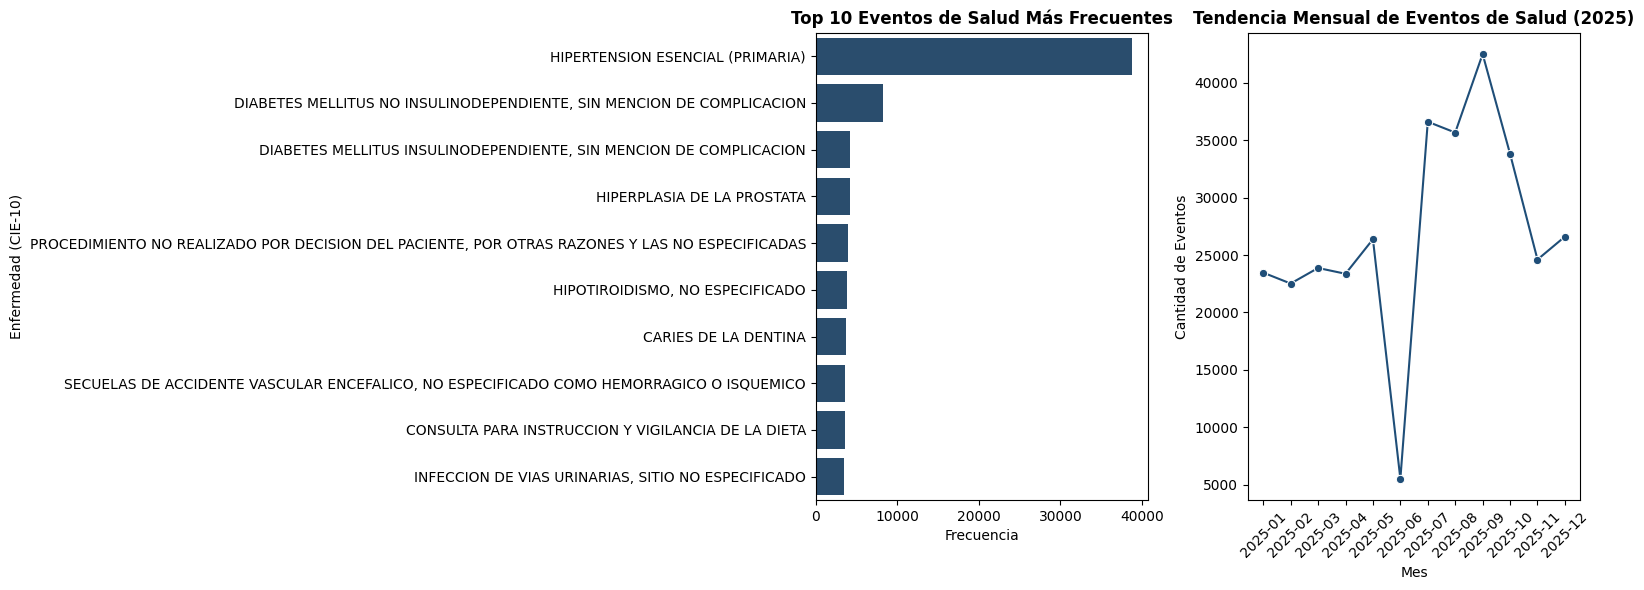

/tmp/ipykernel_1511/396274121.py:27: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(data=df_top, y='MUNICIPIO', hue='SISTEMA', palette=PALETTE_CATEGORICAL)


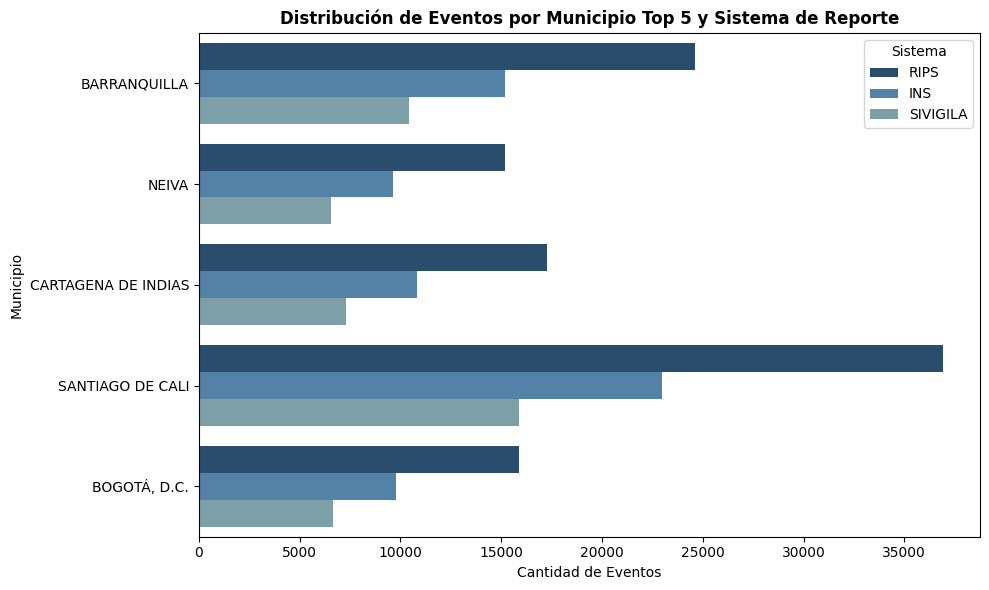

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 enfermedades (NOMBRE) más frecuentes
top_enfermedades = df['NOMBRE'].value_counts().head(10)
sns.barplot(x=top_enfermedades.values, y=top_enfermedades.index, ax=axes[0], color=PRIMARY_COLOR)
axes[0].set_title('Top 10 Eventos de Salud Más Frecuentes', fontweight='bold')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Enfermedad (CIE-10)')

# Tendencia temporal
df['MES'] = df['FECHA REGISTRO'].dt.to_period('M')
tendencia = df.groupby('MES').size().reset_index(name='conteo')
tendencia['MES'] = tendencia['MES'].astype(str)
sns.lineplot(data=tendencia, x='MES', y='conteo', marker='o', ax=axes[1], color=PRIMARY_COLOR)
axes[1].set_title('Tendencia Mensual de Eventos de Salud (2025)', fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad de Eventos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Distribución por Municipio y Sistema de Reporte
plt.figure(figsize=(10, 6))
top_munis = df['MUNICIPIO'].value_counts().head(5).index
df_top = df[df['MUNICIPIO'].isin(top_munis)]
sns.countplot(data=df_top, y='MUNICIPIO', hue='SISTEMA', palette=PALETTE_CATEGORICAL)
plt.title('Distribución de Eventos por Municipio Top 5 y Sistema de Reporte', fontweight='bold')
plt.xlabel('Cantidad de Eventos')
plt.ylabel('Municipio')
plt.legend(title='Sistema')
plt.tight_layout()
plt.show()

Estas gráficas ayudan a entender de manera clara y consisa la información. A diferencia de las gráficas en fases exploratorias, estas gráficas están mas diseñadas a presentar las tendencias más importantes que se encontraron dentro del conjunto de datos. Además de que se puedan comparar las diferentes variables de una manera bastante intuitiva y sencilla además de la facilidad con la que estas gráficas pueden ser exportadas en diferentes formatos, ya sea en pdf, png, entre otros con el fin de adjuntarlos dentro de otro tipo de documentos en comparación con las visualizaciones interactivas que solamente pueden ejecutarse dentro de un espacio.

1. Top 10 eventos más frecuentes: la gráfica muestra los eventos en salud con mayor número de registros dentro del conjunto de datos. Se observa una concentración marcada en enfermedades cardiovasculares y metabólicas —encabezada ampliamente por hipertensión esencial (38.748 casos, casi 5 veces el segundo lugar) y dos variantes de diabetes mellitus—, junto con hiperplasia de próstata, hipotiroidismo, caries de la dentina, secuelas de accidente cerebrovascular e infección de vías urinarias. Es decir, predominan condiciones cardiovasculares, metabólicas/endocrinas, genitourinarias y odontológicas, no respiratorias ni osteomusculares.

2. Tendencia Mensual de eventos en salud: Se osberva dentro de la gráfica una alta volatilidad de los eventos registrados, existen fluctuaciones que van desde  un mínimo aproximado de 5.000 casos hasta un máximo de 42.000. Esta variabilidad se puede ver como factores, tales como eventos epidémiologicos o  otro tipo de factores, tales como un cambio en la actualización de los reportes. Este gráfico puede ser de alta utilidad, debido que las diferentes entidades pueden usar esta tendencia para ver periodos en los que la demanda tiene un incremeneto, y movilizar los diferentes recursos y mecanismos para evitar un colapseo del servicio.
3. Distribución de Eventos por Municipio Top 5 y Sistema de Reporte: se observa como en la ciudad de cali lidera de una manera importante el número de eventos en todos los sistema, especialmente en RIPS, donde supera a ciudades como Barranquilla o Cartagena.  Con todo ello, debido a que esta entidad consolida toda la  información  hospitalaria y ambulatoria. Por otra parte, SIVIGILA reporta información de tipo epidemiológica.



### **2.2. Visualizaciones Interactivas**
---

* Cree visualizaciones interactivas, como gráficos dinámicos o tableros interactivos y proporcione instrucciones claras sobre cómo interactuar con ellos.
* Explore cómo estas visualizaciones ayudan en la exploración de datos y documente su análisis.

In [17]:
df_sunburst = (
    df.groupby(["DEPARTAMENTO", "MUNICIPIO", "GRUPO"])
    .size()
    .reset_index(name="conteo")
)

df_sunburst["total_muni"] = df_sunburst.groupby("MUNICIPIO")[
    "conteo"
].transform("sum")
df_sunburst = df_sunburst[
    (df_sunburst["conteo"] / df_sunburst["total_muni"]) > 0.10
]

fig = px.sunburst(
    df_sunburst,
    path=["DEPARTAMENTO", "MUNICIPIO", "GRUPO"],
    values="conteo",
    title="Jerarquía Geográfica y Epidemiológica de Eventos de Salud",
    color="GRUPO",
    color_discrete_sequence=PALETTE_CATEGORICAL,
)

fig.update_traces(
    textinfo="label+percent entry",
    insidetextorientation="auto",
    insidetextfont=dict(size=10),
)
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))

fig.show()

Las visualizaciones interactivas generadas permiten ver información sobre los eventos de una manera mucho más específica, algo que con un gráfico estático de barras o de cualquier otro tipo sería bastante difícil de observar. Es crucial este tipo de análisis debido a que pueden existir diferente tipo de realidades dentro de los grandes cuidades del país, y los demás centros poblados, que para el caso de nuestro dataset permite ver la manera en que se concentras los pacientes/casos en las grandes ciudades del pais, resultado previsible debido a la mayor capacidad tecnologica y en cuanto a capacidad de las ciudades de Cali, Barranquilla, Bogota y Neiva.

Vale aclarar que el gráfico solo muestra, para cada municipio, los grupos de enfermedad que representan más del 10% de sus casos (para evitar sobrecargar la visualización); por eso los porcentajes visibles de cada municipio no suman necesariamente el 100% de sus eventos.

In [18]:
df_bubble = (
    df.groupby(
        ["MUNICIPIO", "MORTALIDAD"]
    )
    .size()
    .reset_index(name="conteo")
)

fig = px.scatter(
    df_bubble,
    x="conteo",
    y="MUNICIPIO",
    size="conteo",
    color="MORTALIDAD",

    # Escala verde → rojo
    color_continuous_scale="RdYlGn_r",

    hover_name="MUNICIPIO",
    hover_data={
        "conteo": True,
        "MORTALIDAD": True
    },

    title="Eventos de salud por municipio y mortalidad",

    labels={
        "conteo": "Número de eventos",
        "MUNICIPIO": "Municipio",
        "MORTALIDAD": "Mortalidad"
    }
)

fig.update_layout(
    height=max(
        600,
        df_bubble["MUNICIPIO"].nunique() * 30
    )
)

fig.show()

Esta visualizacion interactiva permite analizar el comportamiento de la mortalidad por municipio, ilustrando la frecuencia de cada evento en una escala de burbujas por lo que el tamaño de la burbuja representa que tantos casos de mortalidad se registraron. La escala va de verde a rojo, siendo rojo los casos con mortalidad alta (5) y verde los casos de enfermedades poco mortales (1). Como es evidente los casos de mortalidad baja son mucho mas recurrentes, apreciandose en al grafica una gran cantidad de burbujas colos verde oscuro

### **2.3. Visualización de Mapas Coropléticos (Opcional)**
---

* Si aplica mapas coropléticos para representar datos geoespaciales, incluya estas visualizaciones.
* Explique la elección de este tipo de visualización y cómo ésta contribuye a la comprensión de patrones geográficos y a la solución planteada.

In [19]:
#REPOSITORIO CON LAS COORDENADAS/POLIGONOS DE LOS MUNICIPIOS DE COLOMBIA
url_geo = "https://raw.githubusercontent.com/ytolosa/mapas-colombia/main/output/geojson/col_municipios_inset_nacional.geojson"

geo = gpd.read_file(url_geo)

geo.head(100)

,divipola_mun,divipola_mun_n,divipola_dep,divipola_dep_n,mpio_nombre,dpto_nombre,area_km2,geometry
0,05001,5001,05,5,MEDELLÍN,ANTIOQUIA,374.7415,"POLYGON ((-75.4845 6.191, -75.4985 6.19, -75.5..."
1,05002,5002,05,5,ABEJORRAL,ANTIOQUIA,506.9598,"POLYGON ((-75.4155 5.902, -75.4075 5.901, -75...."
2,05004,5004,05,5,ABRIAQUÍ,ANTIOQUIA,296.9742,"POLYGON ((-76.087 6.7545, -76.074 6.7475, -76...."
3,05021,5021,05,5,ALEJANDRÍA,ANTIOQUIA,128.8564,"POLYGON ((-74.9865 6.385, -74.987 6.3765, -74...."
4,05030,5030,05,5,AMAGÁ,ANTIOQUIA,84.1171,"POLYGON ((-75.6705 5.9985, -75.677 5.998, -75...."
...,...,...,...,...,...,...,...,...
95,05664,5664,05,5,SAN PEDRO DE LOS MILAGROS,ANTIOQUIA,235.2491,"POLYGON ((-75.645 6.4945, -75.633 6.5025, -75...."
96,05665,5665,05,5,SAN PEDRO DE URABÁ,ANTIOQUIA,602.6445,"POLYGON ((-76.4025 8.4635, -76.3975 8.454, -76..."
97,05667,5667,05,5,SAN RAFAEL,ANTIOQUIA,363.6931,"POLYGON ((-75.1165 6.3025, -75.111 6.314, -75...."
98,05670,5670,05,5,SAN ROQUE,ANTIOQUIA,424.5612,"POLYGON ((-74.9865 6.385, -74.9965 6.3875, -75..."


In [ ]:
#por medio de un join crear una union entre geo y mi df, seleccionando solo las columnas necesarias de geo
df_geo = df.merge(geo[['divipola_mun', 'divipola_mun_n', 'divipola_dep', 'divipola_dep_n', 'mpio_nombre', 'dpto_nombre', 'area_km2', 'geometry']], left_on='MUNICIPIO', right_on='mpio_nombre', how='left')
df_geo.head()



,FECHA REGISTRO,DEPARTAMENTO,MUNICIPIO,CIE-10,NOMBRE,DESCRIPCION,SISTEMA,ENTIDAD REPORTA,GRUPO,CONTAGIOSA,...,ES_CONTAGIOSA,MES,divipola_mun,divipola_mun_n,divipola_dep,divipola_dep_n,mpio_nombre,dpto_nombre,area_km2,geometry
0,2025-01-07,ATLÁNTICO,BARRANQUILLA,M199,"ARTROSIS, NO ESPECIFICADA",OTRAS ARTROSIS,RIPS,INS,ENFERMEDADES DEL SISTEMA OSTEOMUSCULAR Y DEL T...,No,...,0,2025-01,08001,8001,08,8,BARRANQUILLA,ATLÁNTICO,154.1276,"POLYGON ((-74.9185 10.9455, -74.9175 10.9545, ..."
1,2025-01-10,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,...,1,2025-01,08001,8001,08,8,BARRANQUILLA,ATLÁNTICO,154.1276,"POLYGON ((-74.9185 10.9455, -74.9175 10.9545, ..."
2,2025-01-13,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,...,1,2025-01,08001,8001,08,8,BARRANQUILLA,ATLÁNTICO,154.1276,"POLYGON ((-74.9185 10.9455, -74.9175 10.9545, ..."
3,2025-01-24,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,RIPS,INS,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,...,1,2025-01,08001,8001,08,8,BARRANQUILLA,ATLÁNTICO,154.1276,"POLYGON ((-74.9185 10.9455, -74.9175 10.9545, ..."
4,2025-01-24,ATLÁNTICO,BARRANQUILLA,B07X,VERRUGAS VIRICAS,VERRUGAS VIRICAS,INS,EAPB,CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS,Si,...,1,2025-01,08001,8001,08,8,BARRANQUILLA,ATLÁNTICO,154.1276,"POLYGON ((-74.9185 10.9455, -74.9175 10.9545, ..."


In [20]:
# Agrupar el DataFrame por DEPARTAMENTO y CONTAGIOSA
df_departamento_contagiosa = df.groupby(['DEPARTAMENTO', 'CONTAGIOSA']).size().unstack(fill_value=0).reset_index()

# Calcular la proporción de casos 'Contagiosa = Si' por departamento
df_departamento_contagiosa['total'] = df_departamento_contagiosa['Si'] + df_departamento_contagiosa['No']
df_departamento_contagiosa['proporcion_contagiosa'] = df_departamento_contagiosa['Si'] / df_departamento_contagiosa['total']

# Preparar las geometrías a nivel de departamento
# Primero, limpiar los nombres de departamento en 'geo' para asegurar la unión
geo['dpto_nombre_cleaned'] = geo['dpto_nombre'].str.strip().str.upper()
df_departamento_contagiosa['DEPARTAMENTO_CLEANED'] = df_departamento_contagiosa['DEPARTAMENTO'].str.strip().str.upper()

# Validar y reparar geometrías antes de disolver
geo_valid = geo.copy()
geo_valid.geometry = geo_valid.geometry.make_valid()

# Disolver las geometrías municipales a nivel departamental
geodata_departamentos = geo_valid.dissolve(by='dpto_nombre_cleaned', aggfunc='first')

# Unir los datos agregados con las geometrías departamentales
map_data_departamentos = geodata_departamentos.merge(df_departamento_contagiosa,left_on='dpto_nombre_cleaned',right_on='DEPARTAMENTO_CLEANED',how='left')

# Rellenar los valores nulos en 'proporcion_contagiosa' con 0 para departamentos sin datos
map_data_departamentos['proporcion_contagiosa'] = map_data_departamentos['proporcion_contagiosa'].fillna(0)

# Crear el mapa coroplético interactivo por departamento
fig = px.choropleth(
    map_data_departamentos,
    geojson=map_data_departamentos.geometry,
    locations=map_data_departamentos.index,
    color='proporcion_contagiosa',
    color_continuous_scale='Plasma',
    hover_name='DEPARTAMENTO',
    hover_data={'proporcion_contagiosa': ':.2%'}, # Formato como porcentaje
    title='Proporción de Casos Contagiosos por Departamento en Colombia'
)

fig.update_geos(fitbounds='locations', visible=False)
fig.show()

In [21]:
prop_contagiosa = df.groupby('DEPARTAMENTO')['CONTAGIOSA'].apply(lambda s: (s == 'Si').mean() * 100).sort_values(ascending=False)
print(prop_contagiosa.round(2))

DEPARTAMENTO
MAGDALENA          5.68
VALLE DEL CAUCA    5.28
BOLÍVAR            3.54
ATLÁNTICO          3.39
CUNDINAMARCA       3.21
HUILA              2.21
SANTANDER          2.05
BOGOTÁ, D.C.       2.02
ANTIOQUIA          1.95
QUINDÍO            1.72
TOLIMA             1.18
Name: CONTAGIOSA, dtype: float64


In [ ]:
# Agrupar el DataFrame por DEPARTAMENTO y CRONICA
df_departamento_cronica = df.groupby(['DEPARTAMENTO', 'CRONICA']).size().unstack(fill_value=0).reset_index()

# Calcular la proporción de casos 'Cronica = Si' por departamento
df_departamento_cronica['total'] = df_departamento_cronica['Si'] + df_departamento_cronica['No']
df_departamento_cronica['proporcion_cronica'] = df_departamento_cronica['Si'] / df_departamento_cronica['total']

# Limpiar el nombre del departamento en df_departamento_cronica para la unión
df_departamento_cronica['DEPARTAMENTO_CLEANED'] = df_departamento_cronica['DEPARTAMENTO'].str.strip().str.upper()

# Unir los datos agregados con las geometrías departamentales
map_data_departamentos_cronica = geodata_departamentos.merge(df_departamento_cronica,left_on='dpto_nombre_cleaned',right_on='DEPARTAMENTO_CLEANED',how='left')

# Rellenar los valores nulos en 'proporcion_cronica' con 0 para departamentos sin datos
map_data_departamentos_cronica['proporcion_cronica'] = map_data_departamentos_cronica['proporcion_cronica'].fillna(0)

# Crear el mapa coroplético interactivo por departamento para casos crónicos
fig_cronica = px.choropleth(
    map_data_departamentos_cronica,
    geojson=map_data_departamentos_cronica.geometry,
    locations=map_data_departamentos_cronica.index,
    color='proporcion_cronica',
    color_continuous_scale='Viridis',
    hover_name='DEPARTAMENTO',
    hover_data={'proporcion_cronica': ':.2%'},
    title='Proporción de Casos Crónicos por Departamento en Colombia'
)

fig_cronica.update_geos(fitbounds='locations', visible=False)
fig_cronica.show()

In [22]:
# Asegurarse de que 'MORTALIDAD' sea numérica para calcular el promedio
df['MORTALIDAD_NUM'] = pd.to_numeric(df['MORTALIDAD'], errors='coerce')

# Agrupar el DataFrame por DEPARTAMENTO y calcular el promedio de MORTALIDAD
df_departamento_mortalidad = df.groupby('DEPARTAMENTO')['MORTALIDAD_NUM'].mean().reset_index()

# Limpiar el nombre del departamento en df_departamento_mortalidad para la unión
df_departamento_mortalidad['DEPARTAMENTO_CLEANED'] = df_departamento_mortalidad['DEPARTAMENTO'].str.strip().str.upper()

# Unir los datos agregados con las geometrías departamentales (geodata_departamentos ya disuelto)
map_data_departamentos_mortalidad = geodata_departamentos.merge(df_departamento_mortalidad,left_on='dpto_nombre_cleaned',right_on='DEPARTAMENTO_CLEANED',how='left')

# Rellenar los valores nulos en 'MORTALIDAD_NUM' con 0
map_data_departamentos_mortalidad['MORTALIDAD_NUM'] = map_data_departamentos_mortalidad['MORTALIDAD_NUM'].fillna(0)

# Crear el mapa coroplético
fig_mortalidad = px.choropleth(
    map_data_departamentos_mortalidad,
    geojson=map_data_departamentos_mortalidad.geometry,
    locations=map_data_departamentos_mortalidad.index,
    color='MORTALIDAD_NUM',
    color_continuous_scale='OrRd',
    hover_name='DEPARTAMENTO',
    hover_data={'MORTALIDAD_NUM': ':.2f'},
    title='Promedio de Mortalidad por Departamento en Colombia'
)

fig_mortalidad.update_geos(fitbounds='locations', visible=False)
fig_mortalidad.show()

In [ ]:
df['MORTALIDAD_NUM'] = pd.to_numeric(df['MORTALIDAD'], errors='coerce')
promedio_mortalidad = df.groupby('DEPARTAMENTO')['MORTALIDAD_NUM'].mean().sort_values(ascending=False)
print(promedio_mortalidad.round(3))

DEPARTAMENTO
BOGOTÁ, D.C.       2.428
TOLIMA             2.170
MAGDALENA          1.892
BOLÍVAR            1.872
ANTIOQUIA          1.854
VALLE DEL CAUCA    1.840
SANTANDER          1.828
QUINDÍO            1.818
ATLÁNTICO          1.738
HUILA              1.680
CUNDINAMARCA       1.648
Name: MORTALIDAD_NUM, dtype: float64


Los mapas coropléticos generados permiten interpretar un mayor entendimiento de la información debido a que es mucho más intuitivo comparar la prevalencia de una variable entre dos departamentos o municipios en un mapa que en una tabla de datos. Los colores y las escalas de color hacen que las diferencias sean evidentes a simple vista, como se explica a continuacion:

1.  **Identificación de Patrones Geográficos y Concentraciones:**
    *   **Hotspots y Coldspots:** Los mapas visualizan de inmediato dónde se concentran los casos (hotspots) y dónde son menos frecuentes (coldspots). Por ejemplo, el mapa de CONTAGIOSA por departamento se observa una proporción de registros que correspoden a enfermedades contagiosas. Por ejemplo,en Magdalena (5,68) y Valle del cauca(5,28), lo que podría indicar la necesidad de campañas de vacunación o medidas de control epidemiológico específicas en esas áreas.
    *   **Desigualdades Regionales:** Permiten identificar rápidamente si hay disparidades importantes entre regiones en términos de la prevalencia de CRONICA o MORTALIDAD. Esto es crucial para entender cómo los factores geográficos, socioeconómicos o de acceso a la salud podrían estar influyendo que como es el caso para nuestra data, estos casos se mayor representacion se encuentra ubicados en las ciudades.

2.  **Contextualización de los Datos:**
    *   **Realidad Geográfica:** Los números y proporciones son más significativos cuando se ubican en su contexto geográfico real. Ver un alto promedio de MORTALIDAD en un municipio específico en el mapa ayuda a vincular el dato abstracto con una ubicación física, como es el caso de Bogotá D.C., que tiene el mayor promedio de mortalidad por departamento (2,43), seguido de Tolima (2,17).
   

3.  **Toma de Decisiones Informada y Focalizada:**
    *   **Asignación de Recursos:** Al identificar las áreas con mayores necesidades (por ejemplo, alta proporcion cronica o mortalidad), las autoridades de salud pueden asignar recursos (personal médico, campañas de prevención, infraestructura de salud) de manera más eficiente y equitativa.
    *   **Diseño de Políticas Públicas:** Los mapas pueden informar el diseño de políticas de salud pública más efectivas, adaptadas a las características y desafíos específicos de cada región o municipio. Por ejemplo, un mapa de MORTALIDAD por municipio puede guiar intervenciones para mejorar la atención médica en las zonas con promedios más altos, ademas son herramientas excelentes para el monitoreo continuo de la situación epidemiológica o de salud, permitiendo observar cómo evolucionan los patrones geográficos con el tiempo.


### **2.4. Interpretación de Resultados**
---
* **¿Existen patrones o tendencias significativas en los datos?**
Sí, se observa como existen muchos casos concentrados en ciudades como Bogotá, Cali, Barranquilla y Cartagena. Seguramente esto tiene que ver con que son los centros urbanos más grandes y donde hay más servicios de salud disponibles. También llaman la atención las cifras altas en problemas respiratorios y osteomusculares.

* **¿Qué significan los resultados en términos prácticos?**
Desde un punto de vista más hacia la salud pública, la frecuencia de enfermedades crónicas en ciudades principales muestra la importancia de fortalecer los servicios de salud, a lo largo de toda la cadena  del servicio. Esto podría alivianar la presión que presentan este grupo de enfermedades al sistema

* **¿Existen patrones o tendencias inesperadas en los datos que requieran una consideración especial?**
Se observó que la mayoría de los registros,lsd  enfermedades contagiosas y crónicas es mutuamente excluyente en la gran mayoría de los registros (validado por el modelo logístico). Esto es coherente clínicamente, pero resalta la importancia de separar las estrategias de salud pública: mientras las infecciosas requieren campañas de vacunación y saneamiento, las crónicas requieren programas de manejo a largo plazo.

* **¿Cuáles fueron los hallazgos principales que contribuirán al proceso de toma de decisiones?**
La modelación logística permitió identificar qué grupos CIE-10 tienen mayor probabilidad de enfermedades crónicas. Esto es insumo directo para que las EAPB (Entidades Administradoras de Planes de Beneficios) asignen presupuestos, priorizando la compra de servicios de especialidad para los grupos clínicos que el modelo identificó con mayor riesgo.

## **3. Conclusiones**
---
Asegúrese de incluir al menos una conclusión de cada unidad tratada en los *notebooks*. Estas conclusiones actúan como resúmenes breves que destacan los puntos clave y los aprendizajes esenciales de cada sección.


1. Fue sumamente relevante entender la naturaleza de los datos en el entendimiento del negocio, los que permitió esbozar como podrian ser tratados los datos en los pasos siguientes como el de limpieza, visualizacion y tambien sacar las variables redundantes.
2. La rigurosidad de la limpieza y preparación de la información demostró ser un requisito indispensable para la validez de cualquier análisis posterior. La identificación y la eliminación de un volumen crítico dentro del conjunto de datos, permitieron depurar datos que no habrian sido concluyentes.
3. La adaptación de tecnicas estadísticas de naturaleza categorica de los datos(uso de pruebas Chi-cuadrado, y el coeficiente V de Cramer) permitió validar el conjunto de datos, teniendo en cuenta la naturaleza de este mismo. Se demostró una asociación estadísticamente significante dentro de los Macro-Grupos y de la clasificación CIE-10 y la naturaleza crónica y contagiosa. Con ello, se logró verificar la estructura de este conjunto de datos, además de poder estimar la carga de enfermedades de larga duración. Por su parte, el modelo de regresión logística permitió cuantificar con confianza que un evento contagioso tiene apenas el 1,5% de probabilidad de ser clasificado como crónico frente a uno no contagioso, aunque su lectura grupo por grupo (por GRUPO CIE-10) requirió excluir 5 categorías con separación perfecta para que el modelo convergiera.
4. El análisis exploratorio y las visualizaciones revelaron una alta concentración de eventos en salud en los principales centros urbanos del país. Este comportamiento está directamente relacionado con la densidad de la población y la gama de servicios que se ofrecen dentro de estos centros urbanos, todo ello evidencia una nesecidad epidiemológica como de la red de atención  
5. Los hallazgos dentro del análisis proporcionan una base empírica sólida que indica las políticas de intervención y asignación de recursos que no deben ser homogenizados a nivel nacional. Los resultados permiten a los diferetes actores de la prestación de salud a nivel colombiano, tales como EAPB, ADRES, entre otros priorizar estrategias de manera diferenciada. Mientras que las grandes urbes requieren un enfoque robusto en el manejo ambulatorio de la cronicidad y de salud mental. Los municipios intermedios podrían beneficiarse de campañas focalizadas de prevención y de vigilancia epideomologíca, optimizando asi la eficiencia y la equidad dentro del sistema de salud.




## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    
**Universidad Nacional de Colombia** - *Facultad de Ingeniería*